stat_fun(H1): min=-2.330043951333978 max=4.2037360047295795
Running initial clustering …
Found 20 clusters


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:605: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]


Control
Significant samples: 37
Cluster 3: p=0.0238, 468.0 to 612.0 ms
stat_fun(H1): min=-2.160593807428211 max=3.595358615333581
Running initial clustering …
Found 8 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]


Depressed
Significant samples: 48
Cluster 2: p=0.0018, 436.0 to 624.0 ms
stat_fun(H1): min=-1.8326813518012612 max=5.018834650664741
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]


Suicidal
Significant samples: 61
Cluster 2: p=0.0022, 292.0 to 532.0 ms


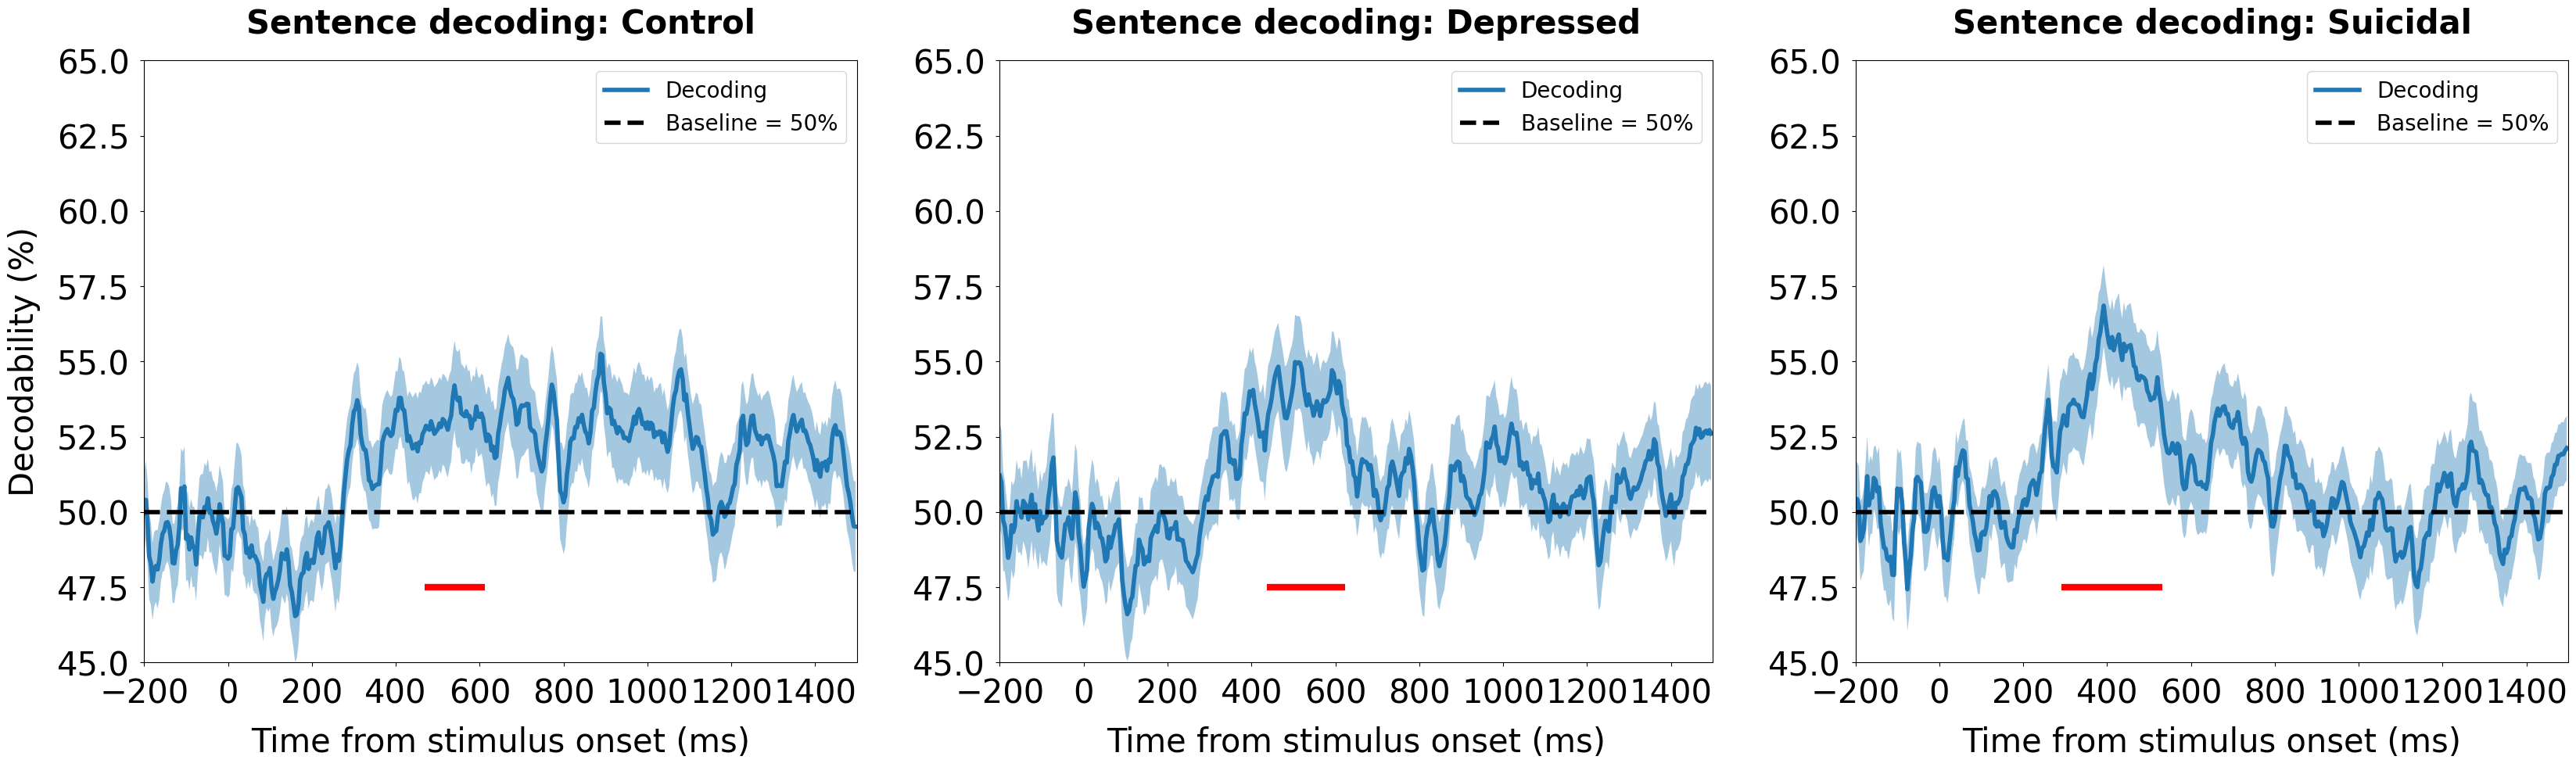

Saved figure:
/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/SourceLoc/Results/CBP_Chance/figure_CBP_same_format.pdf


In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import mat73

from scipy.stats import ttest_ind
from scipy.stats import t as tdist
from mne.stats import permutation_cluster_test


# ============================================================
# Fixed CBP function
# ============================================================
def stat_fun_timeseries(x, y):
    tvals, _ = ttest_ind(
        x,
        y,
        axis=0,
        equal_var=False,
        nan_policy="omit",
    )
    return tvals


def cluster_to_mask(cluster, shape):
    mask = np.zeros(shape, dtype=bool)

    if isinstance(cluster, tuple):
        mask[cluster] = True
    else:
        arr = np.asarray(cluster)

        if arr.dtype == bool:
            mask |= arr
        else:
            mask[arr.astype(int)] = True

    return mask


def cluster_based_permutation_test_timeseries_fixed(
    data1,
    data2,
    n_permutations=5000,
    threshold_p=0.05,
    cluster_alpha=0.05,
    tail=1,
    seed=42,
    n_jobs=-1,
):
    data1 = np.asarray(data1, dtype=np.float64)
    data2 = np.asarray(data2, dtype=np.float64)

    df = data1.shape[0] + data2.shape[0] - 2

    if tail == 0:
        threshold = tdist.ppf(1 - threshold_p / 2, df)
    elif tail == 1:
        threshold = tdist.ppf(1 - threshold_p, df)
    elif tail == -1:
        threshold = -tdist.ppf(1 - threshold_p, df)
    else:
        raise ValueError("tail must be 0, 1, or -1.")

    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
        [data1, data2],
        stat_fun=stat_fun_timeseries,
        n_permutations=n_permutations,
        threshold=threshold,
        tail=tail,
        out_type="indices",
        seed=seed,
        n_jobs=n_jobs,
    )

    sig_mask = np.zeros(T_obs.shape, dtype=bool)

    for cluster, pval in zip(clusters, cluster_p_values):
        if pval < cluster_alpha:
            sig_mask |= cluster_to_mask(cluster, T_obs.shape)

    return sig_mask, T_obs, clusters, cluster_p_values


def plot_sig_line(time_vec, sig_mask, y=47.5, color="red", linewidth=6):
    sig_mask = np.asarray(sig_mask, dtype=bool)

    if not np.any(sig_mask):
        return

    idx = np.where(sig_mask)[0]
    clusters = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)

    for clu in clusters:
        plt.plot(
            time_vec[clu],
            np.ones(len(clu)) * y,
            color=color,
            linewidth=linewidth,
            solid_capstyle="butt",
            label="_nolegend_",
        )


# ============================================================
# Load data
# ============================================================
fpath = "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/SourceLoc/Results/svmDecoding_source_3pc.pkl"

with open(fpath, "rb") as file:
    decodeSen = pickle.load(file)["decodeScore"] * 100

decodeSen = np.asarray(decodeSen, dtype=np.float64)

fName = "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Data/Behavior/subject_index.mat"
Idx = mat73.loadmat(fName)["subject_index"].squeeze()

cId = np.where(Idx == 1)[0]
dId = np.where(Idx == 2)[0]
sId = np.where(Idx == 3)[0]

time_vec = np.arange(-200, 1500, 4)

if len(time_vec) != decodeSen.shape[1]:
    raise ValueError(
        f"Time mismatch: len(time_vec)={len(time_vec)}, "
        f"data time={decodeSen.shape[1]}"
    )


# ============================================================
# Run CBP against 50%
# ============================================================
groups = {
    "Control": cId,
    "Depressed": dId,
    "Suicidal": sId,
}

sig_results = {}

for group_name, ids in groups.items():

    group_data = decodeSen[ids, :]
    chance_data = np.ones_like(group_data) * 50.0

    sig_mask, T_obs, clusters, cluster_p_values = (
        cluster_based_permutation_test_timeseries_fixed(
            data1=group_data,
            data2=chance_data,
            n_permutations=5000,
            threshold_p=0.05,
            cluster_alpha=0.05,
            tail=1,
            seed=42,
            n_jobs=-1,
        )
    )

    sig_results[group_name] = sig_mask

    print(f"\n{group_name}")
    print("Significant samples:", np.sum(sig_mask))

    for i, pval in enumerate(cluster_p_values):
        if pval < 0.05:
            clu_mask = cluster_to_mask(clusters[i], T_obs.shape)
            sig_times = time_vec[clu_mask]

            if len(sig_times) > 0:
                print(
                    f"Cluster {i}: p={pval:.4f}, "
                    f"{sig_times[0]:.1f} to {sig_times[-1]:.1f} ms"
                )


# ============================================================
# Plot with same format
# ============================================================
plt.figure(figsize=(40, 10))


# ------------------------------------------------------------
# Control
# ------------------------------------------------------------
m = np.mean(decodeSen[cId, :], axis=0)
err = np.std(decodeSen[cId, :], axis=0) / np.sqrt(len(cId))

plt.subplot(1, 3, 1)
plt.plot(time_vec, m, linewidth=4)
plt.plot(
    time_vec, np.ones(time_vec.shape[0]) * 50, linewidth=4, linestyle="--", color="k"
)
plt.fill_between(time_vec, m - err, m + err, alpha=0.4, linewidth=4, label="_nolegend_")

plot_sig_line(time_vec, sig_results["Control"], y=47.5, color="red", linewidth=6)

plt.xlabel("Time from stimulus onset (ms)", fontsize=30, labelpad=15)
plt.ylabel("Decodability (%)", fontsize=30, labelpad=15)
plt.title("Sentence decoding: Control", fontsize=30, fontweight="bold", pad=25)
plt.legend(["Decoding", "Baseline = 50%", "p < 0.05"], fontsize=20)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylim(45, 65)
plt.tick_params(axis="both", pad=10)
plt.xlim(-200, 1500)


# ------------------------------------------------------------
# Depressed
# ------------------------------------------------------------
m = np.mean(decodeSen[dId, :], axis=0)
err = np.std(decodeSen[dId, :], axis=0) / np.sqrt(len(dId))

plt.subplot(1, 3, 2)
plt.plot(time_vec, m, linewidth=4)
plt.plot(
    time_vec, np.ones(time_vec.shape[0]) * 50, linewidth=4, linestyle="--", color="k"
)
plt.fill_between(time_vec, m - err, m + err, alpha=0.4, linewidth=4, label="_nolegend_")

plot_sig_line(time_vec, sig_results["Depressed"], y=47.5, color="red", linewidth=6)

plt.xlabel("Time from stimulus onset (ms)", fontsize=30, labelpad=15)
plt.title("Sentence decoding: Depressed", fontsize=30, fontweight="bold", pad=25)
plt.legend(["Decoding", "Baseline = 50%", "p < 0.05"], fontsize=20)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylim(45, 65)
plt.tick_params(axis="both", pad=10)
plt.xlim(-200, 1500)


# ------------------------------------------------------------
# Suicidal
# ------------------------------------------------------------
m = np.mean(decodeSen[sId, :], axis=0)
err = np.std(decodeSen[sId, :], axis=0) / np.sqrt(len(sId))

plt.subplot(1, 3, 3)
plt.plot(time_vec, m, linewidth=4)
plt.plot(
    time_vec, np.ones(time_vec.shape[0]) * 50, linewidth=4, linestyle="--", color="k"
)
plt.fill_between(time_vec, m - err, m + err, alpha=0.4, linewidth=4, label="_nolegend_")

plot_sig_line(time_vec, sig_results["Suicidal"], y=47.5, color="red", linewidth=6)

plt.xlabel("Time from stimulus onset (ms)", fontsize=30, labelpad=15)
plt.title("Sentence decoding: Suicidal", fontsize=30, fontweight="bold", pad=25)
plt.legend(["Decoding", "Baseline = 50%", "p < 0.05"], fontsize=20)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylim(45, 65)
plt.tick_params(axis="both", pad=10)
plt.xlim(-200, 1500)


# ============================================================
# Save/show
# ============================================================
save_path = "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/SourceLoc/Results/CBP_Chance/figure_svmDecoding.pdf"

os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(
    save_path,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(save_path)